# CMMD Breast Regions

Visualize breast bounding boxes from `CMMD_breast_region_fixed.csv` overlaid on the corresponding DICOM images.

In [2]:
import ast
import csv
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(Path.cwd().parent))

#from src.preprocessing import load_dicom_pixels

# CMMD dataset root directory
CMMD_ROOT = Path.home() / 'Escritorio/Datasets/CMMD'
CMMD_CSV = CMMD_ROOT / 'CMMD_breast_region_fixed.csv'

In [4]:
# Load CSV into a list of dicts
with CMMD_CSV.open(newline='', encoding='utf-8') as f:
    records = list(csv.DictReader(f))

print(f"Total annotations: {len(records)}")
print("Sample row:", records[0])

Total annotations: 5202
Sample row: {'file_name': 'cmmd/D1-0001/79377/70244/608a073d-14ef-455b-be5d-f73f553b97f0.dcm', 'bboxes': '[1325.429443359375, 406.74835205078125, 1924.5091552734375, 2109.11279296875]', 'scores': '0.98611134'}


In [ ]:
idx = random.randint(0, len(records)-1)
image_path = CMMD_ROOT / records[idx]['file_name']

print(f'Total de imagenes DICOM: {len(records)}')
print(f'Index: {idx}')
print(f'Imagen: {records[idx]["file_name"]}')


Total de imagenes DICOM: 5202
Index: 548
Imagen: cmmd/D1-0389/81491/80813/0df2c831-8570-479d-a616-9bb461a5fb80.dcm


## Metadatos y preprocesado
Esta seccion muestra una mamografia tras aplicar windowing y segmentacion de fondo, junto con una superposicion de la mascara sobre la imagen original.

In [14]:
import matplotlib.pyplot as plt
import pydicom 

from src.preprocessing import (
    apply_background_mask,
    # apply_windowing,
    load_dicom_pixels,
    read_dicom_metadata,
    #segment_breast_region,
)

from src.apply_windowing import *
from src.calculate_windowing import(
    get_dicom_voi_lut_params, 
    calculate_windowing, 
    should_invert_monochrome1, 
    normalize_photometric,
)

In [15]:
## Imagen de lista
#image_path = list_dicom_images(DEFAULT_INBREAST_IMAGES_DIR)[idx]
image_path = CMMD_ROOT / records[idx]['file_name']

### metadata <==> dcm
metadata = pydicom.dcmread(image_path)
print(metadata)

original_image = metadata.pixel_array

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 208
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.136089727357483422271241516141
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0012) Instance Creation Date              DA: '20170818'
(0008,0013) Instance Creation Time              TM: '115453'
(0008,0014) Inst

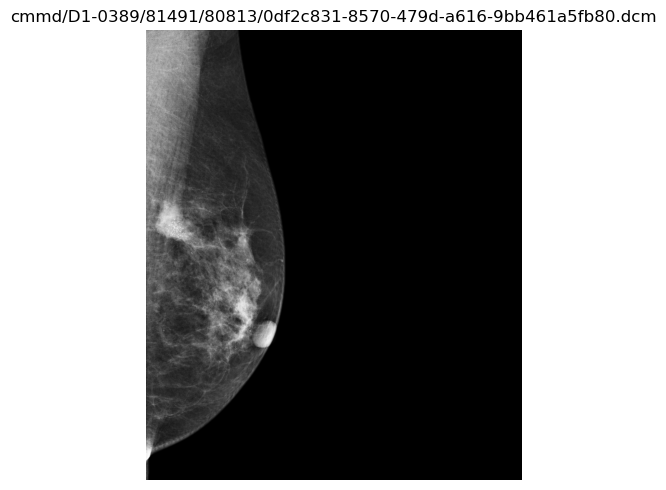

In [27]:
# figure, axis, image = show_dicom_image(image_index=idx)
figsize = (5, 5)

figure, axis = plt.subplots(figsize=figsize)
axis.imshow(original_image, cmap='gray')
axis.set_title(records[idx]['file_name'])
axis.axis("off")
figure.tight_layout()

## Photometric normalization

In [18]:
## Creo que normalize photometric ya hace la comprobación de si hay que invertir o no, pero por si acaso lo dejo
print(should_invert_monochrome1(metadata) )

#if should_invert_monochrome1(metadata):
original_image, _ = normalize_photometric(original_image, metadata)

False


## Windowing

In [ ]:
# center, width = calculate_windowing(original_image) ## cambiar por 
voilut = get_dicom_voi_lut_params(metadata)
print(voilut)


# windowed_image = apply_windowing(load_dicom_pixels(image_path))
windowed_image = apply_windowing(original_image,
                                 window_width = voilut['window_width'],
                                 window_center = voilut['window_center'],
                                 voi_func = voilut['voi_lut_function'],
                                 y_min = original_image.min(),
                                 y_max =  original_image.max(), 
                                 backend = 'np_v2')

(0008,0005): (0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008): (0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0012): (0008,0012) Instance Creation Date              DA: '20170818'
(0008,0013): (0008,0013) Instance Creation Time              TM: '115453'
(0008,0014): (0008,0014) Instance Creator UID                UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.256693145395574474618647257749
(0008,0016): (0008,0016) SOP Class UID                       UI: Digital Mammography X-Ray Image Storage - For Presentation
(0008,0018): (0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.136089727357483422271241516141
(0008,0020): (0008,0020) Study Date                          DA: '20100718'
(0008,0021): (0008,0021) Series Date                         DA: '20100718'
(0008,0022): (0008,0022) Acquisition Date                    DA: '20100718'
(0008,0023): (0008,0023) Content Date                        DA: '201007

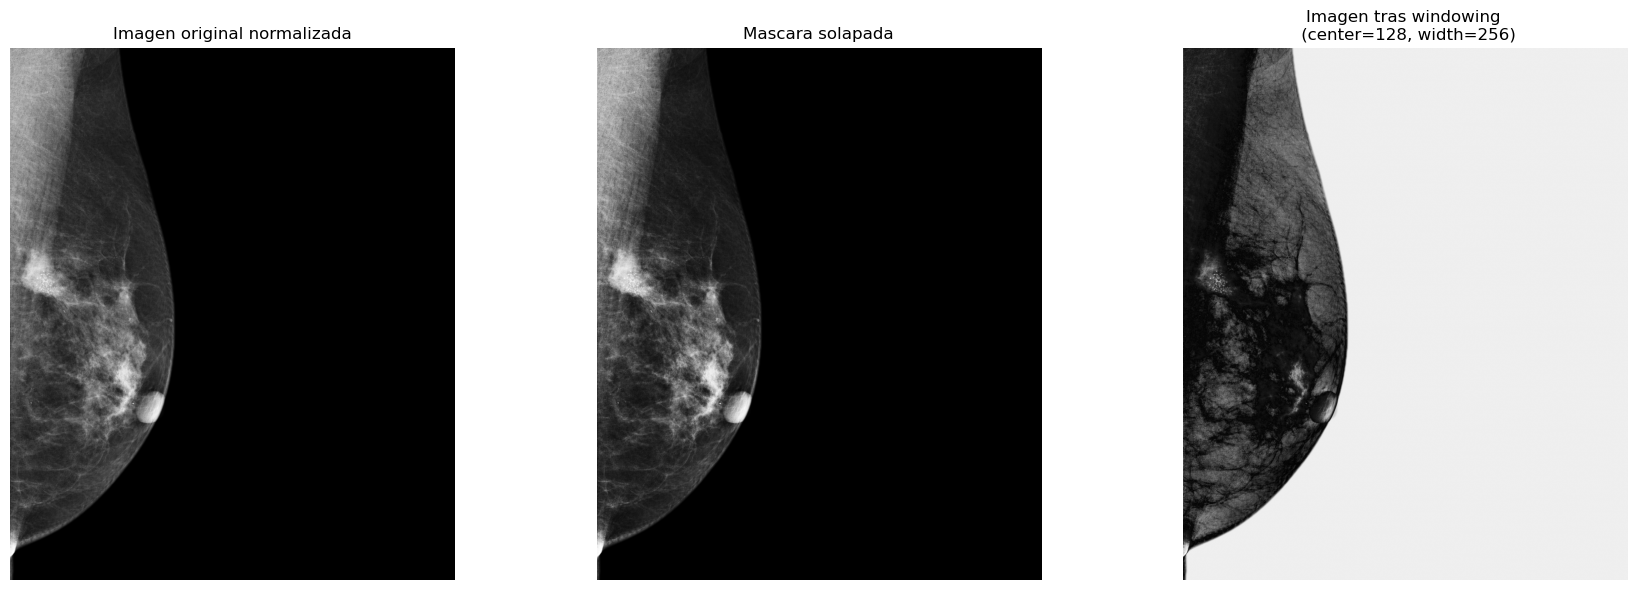

In [ ]:
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original normalizada')
axes[0].axis('off')

axes[1].imshow(windowed_image, cmap='gray')
#axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title(f'Imagen tras windowing \n (center={voilut["window_center"]}, width={voilut["window_width"]})')
axes[1].axis('off')

axes[2].imshow(np.abs(windowed_image - original_image), cmap='gray')
#axes[2].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[2].set_title(f'Imagen de diferencia entre original y windowed')
axes[2].axis('off')

figure.tight_layout()

visible_metadata = {
    key: value
    for key, value in metadata.items()
    if value not in (None, '', [], {})
}

for key, value in visible_metadata.items():
    print(f'{key}: {value}')

In [24]:
print(original_image)
print(windowed_image)
print(np.abs(windowed_image - original_image))

[[212 164 144 ...   0   0   0]
 [206 161 138 ...   0   0   0]
 [194 156 120 ...   0   0   0]
 ...
 [ 72  72  60 ...   0   0   0]
 [ 72  65  62 ...   0   0   0]
 [ 68  72  74 ...   0   0   0]]
[[197.77074  159.89473  141.10631  ...  29.919937  29.919937  29.919937]
 [193.73271  157.15718  135.28479  ...  29.919937  29.919937  29.919937]
 [185.0267   152.52345  117.66645  ...  29.919937  29.919937  29.919937]
 ...
 [ 73.84795   73.84795   64.46483  ...  29.919937  29.919937  29.919937]
 [ 73.84795   68.27816   65.9733   ...  29.919937  29.919937  29.919937]
 [ 70.63281   73.84795   75.48714  ...  29.919937  29.919937  29.919937]]
[[14.229263   4.1052704  2.893692  ... 29.919937  29.919937  29.919937 ]
 [12.267288   3.8428192  2.71521   ... 29.919937  29.919937  29.919937 ]
 [ 8.973297   3.4765472  2.3335495 ... 29.919937  29.919937  29.919937 ]
 ...
 [ 1.8479538  1.8479538  4.4648285 ... 29.919937  29.919937  29.919937 ]
 [ 1.8479538  3.27816    3.973297  ... 29.919937  29.919937  29.919

[[212 164 144 ...   0   0   0]
 [206 161 138 ...   0   0   0]
 [194 156 120 ...   0   0   0]
 ...
 [ 72  72  60 ...   0   0   0]
 [ 72  65  62 ...   0   0   0]
 [ 68  72  74 ...   0   0   0]]
[[226.41835  175.3264   149.98222  ...   0.         0.         0.      ]
 [220.97136  171.63367  142.12941  ...   0.         0.         0.      ]
 [209.2276   165.3831   118.36358  ...   0.         0.         0.      ]
 ...
 [ 59.255657  59.255657  46.59851  ...   0.         0.         0.      ]
 [ 59.255657  51.742413  48.63332  ...   0.         0.         0.      ]
 [ 54.918667  59.255657  61.46679  ...   0.         0.         0.      ]]
[[14.41835   11.326401   5.9822235 ...  0.         0.         0.       ]
 [14.971359  10.633667   4.12941   ...  0.         0.         0.       ]
 [15.2276     9.383102   1.6364212 ...  0.         0.         0.       ]
 ...
 [12.744343  12.744343  13.401489  ...  0.         0.         0.       ]
 [12.744343  13.257587  13.36668   ...  0.         0.         0.   

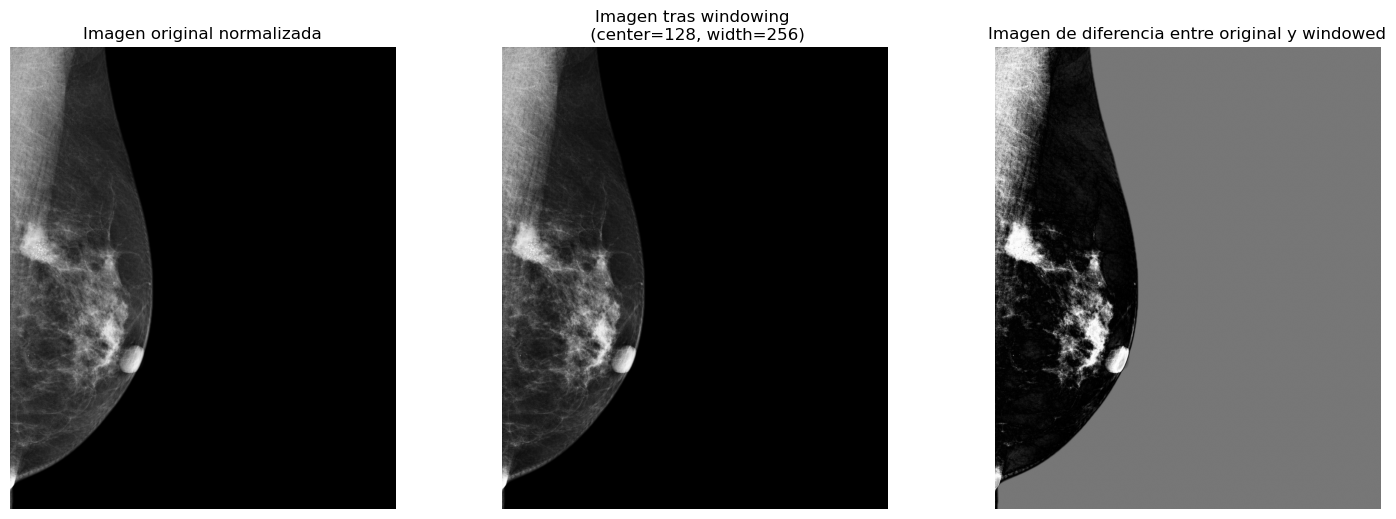

In [28]:
normalized_windowed = 255*(windowed_image-windowed_image.min())/(windowed_image.max()-windowed_image.min())
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original normalizada')
axes[0].axis('off')

axes[1].imshow(normalized_windowed, cmap='gray')
#axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title(f'Imagen tras windowing \n (center={voilut["window_center"]}, width={voilut["window_width"]})')
axes[1].axis('off')

axes[2].imshow(normalized_windowed - original_image, cmap='gray')
#axes[2].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[2].set_title(f'Imagen de diferencia entre original y windowed')
axes[2].axis('off')

print(original_image)
print(normalized_windowed)
print(np.abs(normalized_windowed - original_image))

## Breast bounding boxes

In [3]:
def show_dicom_with_bbox(record, cmmd_root=CMMD_ROOT, ax=None):
    """Display a DICOM image with its breast bounding box.

    Parameters
    ----------
    record : dict
        Row from CMMD_breast_region_fixed.csv with 'file_name' and 'bboxes'.
    cmmd_root : Path, optional
        Root directory of the CMMD dataset. Defaults to CMMD_ROOT.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, a new figure is created.
    """
    # Build full path from relative path in CSV
    path = Path(cmmd_root) / record['file_name']
    # bboxes format: [x1, y1, x2, y2]
    x1, y1, x2, y2 = ast.literal_eval(record['bboxes'])
    score = float(record['scores'])

    pixels = load_dicom_pixels(path, normalize=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 8))

    ax.imshow(pixels, cmap='gray', aspect='equal')

    rect = mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='lime', facecolor='none',
        label=f'breast (score={score:.3f})'
    )
    ax.add_patch(rect)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(path.stem, fontsize=8)
    ax.axis('off')
    return ax

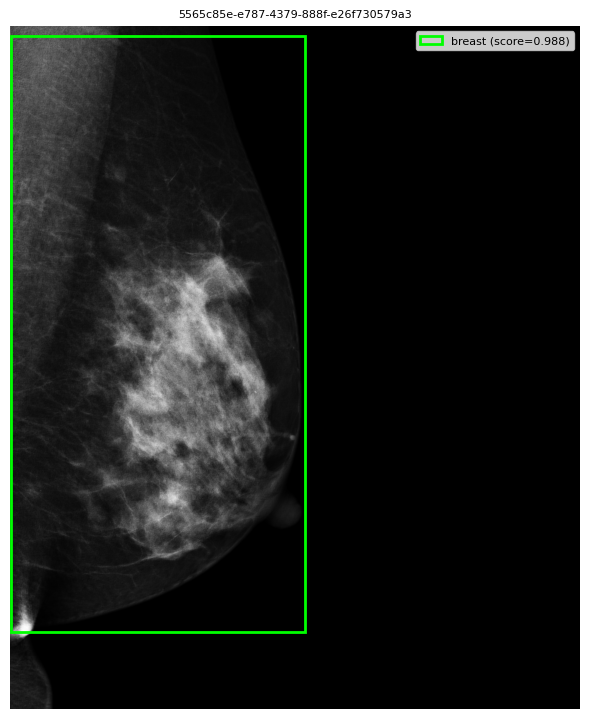

In [4]:
# Show a single random example
record = random.choice(records)
show_dicom_with_bbox(record)
plt.tight_layout()
plt.show()

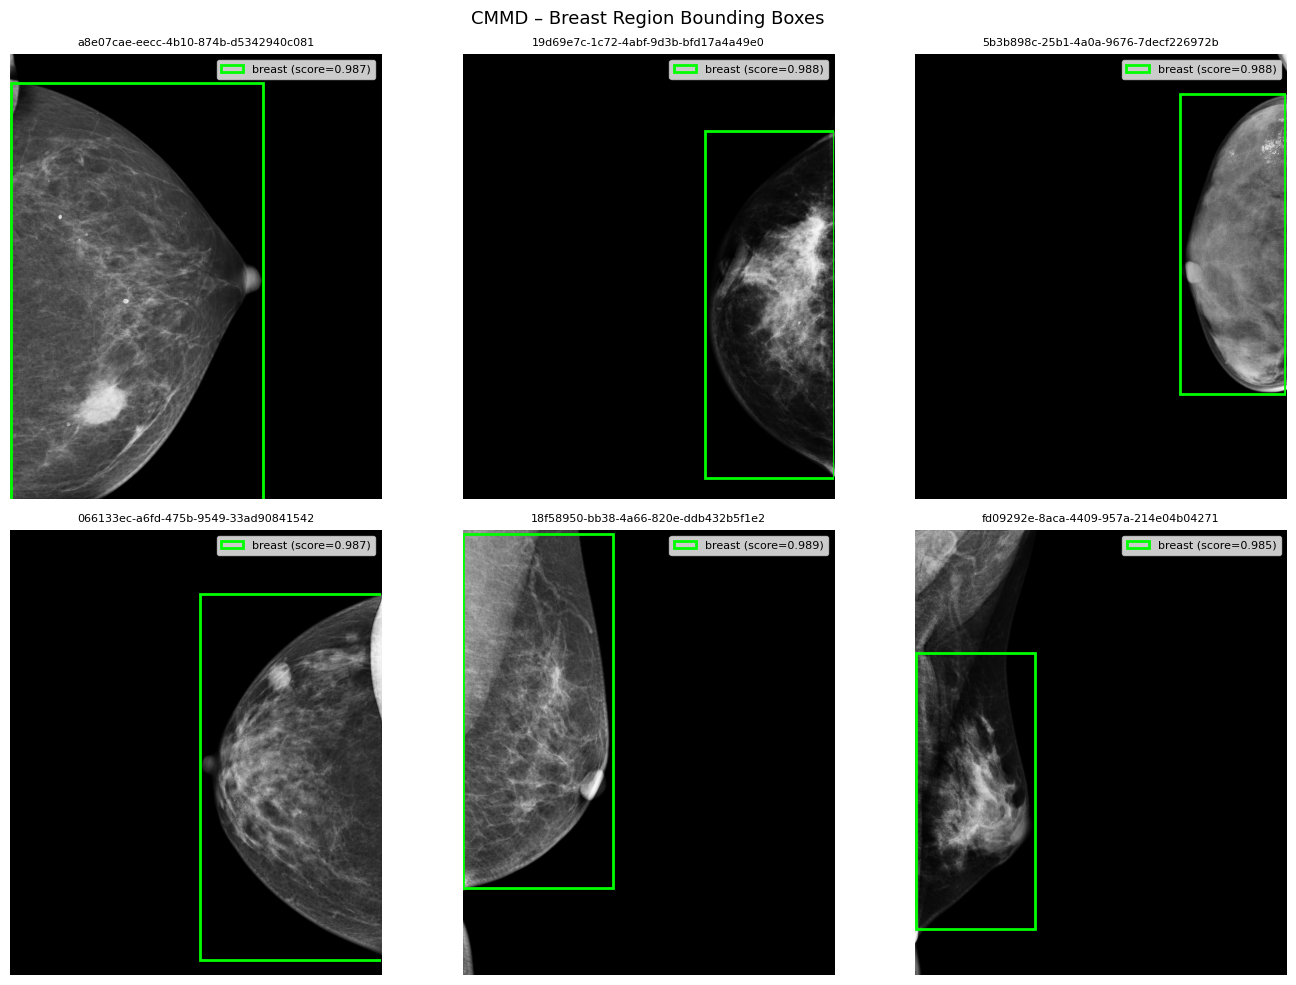

In [5]:
# Show a 2×3 grid of random examples
sample = random.sample(records, 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, rec in zip(axes.flat, sample):
    show_dicom_with_bbox(rec, ax=ax)
plt.suptitle('CMMD – Breast Region Bounding Boxes', fontsize=13)
plt.tight_layout()
plt.show()

Found 2 annotations for D1-0091


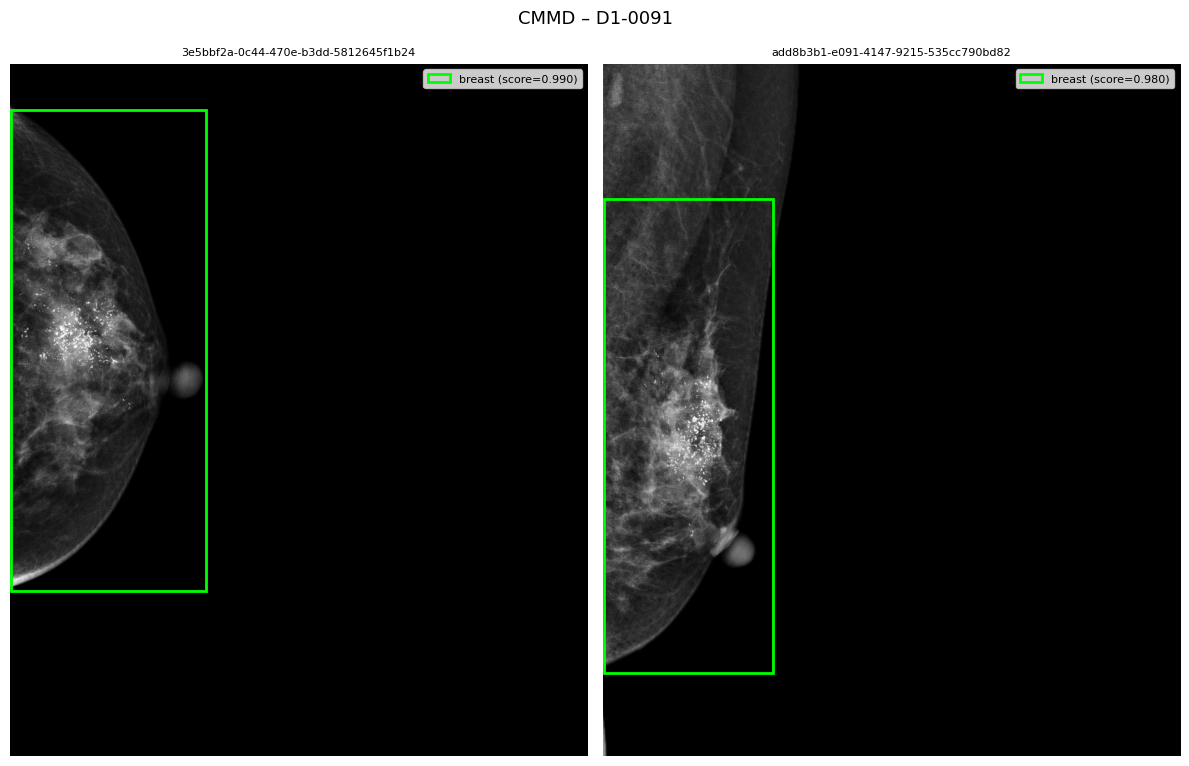

In [8]:
# Show a specific case by index or case ID
CASE_ID = 'D1-0091'  # change as needed

case_records = [r for r in records if CASE_ID in r['file_name']]
print(f"Found {len(case_records)} annotations for {CASE_ID}")

if case_records:
    n = len(case_records)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 8))
    if n == 1:
        axes = [axes]
    for ax, rec in zip(axes, case_records):
        show_dicom_with_bbox(rec, ax=ax)
    plt.suptitle(f'CMMD – {CASE_ID}', fontsize=13)
    plt.tight_layout()
    plt.show()